In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [4]:
e = df = pd.read_csv('E-com_Data.csv')
df.head()

,CustomerID,Item Code,InvoieNo,Date of purchase,Quantity,Time,price per Unit,Price,Shipping Location,Cancelled_status,Reason of return,Sold as set
0,4355.0,15734,398177.0,29-10-2017,6.0,3:36:00 PM,321.0,1926.0,Location 1,NaN,NaN,NaN
1,4352.0,14616,394422.0,05-10-2017,2.0,2:53:00 PM,870.0,1740.0,Location 1,NaN,NaN,NaN
2,4352.0,14614,394422.0,12-10-2017,2.0,2:53:00 PM,933.0,1866.0,Location 1,NaN,NaN,NaN
3,4352.0,85014B,388633.0,22-08-2017,3.0,2:47:00 PM,623.0,1869.0,Location 1,NaN,NaN,NaN
4,4352.0,15364,394422.0,10-10-2017,2.0,2:53:00 PM,944.0,1888.0,Location 1,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541116 entries, 0 to 541115
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         404189 non-null  float64
 1   Item Code          537979 non-null  object 
 2   InvoieNo           537979 non-null  float64
 3   Date of purchase   537979 non-null  object 
 4   Quantity           537979 non-null  float64
 5   Time               537979 non-null  object 
 6   price per Unit     537979 non-null  float64
 7   Price              537979 non-null  float64
 8   Shipping Location  537979 non-null  object 
 9   Cancelled_status   8345 non-null    object 
 10  Reason of return   3 non-null       object 
 11  Sold as set        0 non-null       float64
dtypes: float64(6), object(6)
memory usage: 49.5+ MB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,404189.0,2181.909035,1252.681881,2.0,1207.0,2078.0,3291.0,4372.0
InvoieNo,537979.0,385017.572063,13426.052649,361429.0,372961.0,385706.0,396873.0,406651.0
Quantity,537979.0,9.343339,27.623322,-2003.0,1.0,3.0,10.0,3186.0
price per Unit,537979.0,378.339062,440.048823,1.0,169.0,261.0,456.0,64973.0
Price,537979.0,2161.414593,4538.487177,-10152.0,451.0,1194.0,2232.0,90400.0
Sold as set,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.columns

Index(['CustomerID', 'Item Code', 'InvoieNo', 'Date of purchase', 'Quantity',
       'Time', 'price per Unit', 'Price', 'Shipping Location',
       'Cancelled_status', 'Reason of return', 'Sold as set'],
      dtype='object')

In [8]:
drop_columns = ['Item Code','Quantity','price per Unit','Time','Shipping Location','Cancelled_status','Reason of return','Sold as set']
df.drop(columns = drop_columns, inplace = True)

In [9]:
df.head()

,CustomerID,InvoieNo,Date of purchase,Price
0,4355.0,398177.0,29-10-2017,1926.0
1,4352.0,394422.0,05-10-2017,1740.0
2,4352.0,394422.0,12-10-2017,1866.0
3,4352.0,388633.0,22-08-2017,1869.0
4,4352.0,394422.0,10-10-2017,1888.0


In [10]:
df.duplicated().sum()

np.int64(6008)

In [11]:
df.drop_duplicates(inplace = True)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.Price.min()

-10152.0

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,402859.0,2182.187224,1252.636483,2.0,1207.0,2078.0,3291.0,4372.0
InvoieNo,535107.0,385009.702116,13418.210488,361429.0,372964.0,385665.0,396811.0,406651.0
Price,535107.0,2167.848915,4547.338495,-10152.0,453.0,1200.0,2236.0,90400.0


In [15]:
def missing_values(df):
  missing_number = df.isnull().sum().sort_values(ascending = False)
  missing_percent = (df.isnull().sum()/df.isnull().count()*100).sort_values(ascending = False)
  missing_values = pd.concat([missing_number,missing_percent],keys  = ['missing_number','missing_percent'], axis = 1)
  return missing_values[missing_values['missing_number']>0]
missing_values(df)

,missing_number,missing_percent
CustomerID,132249,24.714450
InvoieNo,1,0.000187
Date of purchase,1,0.000187
Price,1,0.000187


In [16]:
df = df.dropna(subset = ['CustomerID'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 402859 entries, 0 to 537949
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   CustomerID        402859 non-null  float64
 1   InvoieNo          402859 non-null  float64
 2   Date of purchase  402859 non-null  object 
 3   Price             402859 non-null  float64
dtypes: float64(3), object(1)
memory usage: 15.4+ MB


In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,402859.0,2182.187224,1252.636483,2.0,1207.0,2078.0,3291.0,4372.0
InvoieNo,402859.0,385642.971491,13106.663884,361429.0,374193.0,386934.0,397130.0,406651.0
Price,402859.0,2477.465103,4896.268647,-10152.0,556.0,1572.0,2496.0,90400.0


In [18]:
df['Date of purchase'] = pd.to_datetime(df['Date of purchase'])

In [19]:
df['Date of purchase'].describe().T

,Date of purchase
count,402859
mean,2017-07-15 14:25:02.538605056
min,2016-12-02 00:00:00
25%,2017-04-12 00:00:00
50%,2017-08-05 00:00:00
75%,2017-10-26 00:00:00
max,2017-12-19 00:00:00


In [20]:
df = df.rename(columns = {'InvoieNo':'InvoiceNo','Date of purchase':'Date'})

In [21]:
df.head()

,CustomerID,InvoiceNo,Date,Price
0,4355.0,398177.0,2017-10-29,1926.0
1,4352.0,394422.0,2017-10-05,1740.0
2,4352.0,394422.0,2017-10-12,1866.0
3,4352.0,388633.0,2017-08-22,1869.0
4,4352.0,394422.0,2017-10-10,1888.0


In [22]:
df['CustomerID'].nunique()

4349

In [23]:
import datetime
new_date = datetime.datetime(2017,12,20)
new_date

datetime.datetime(2017, 12, 20, 0, 0)

In [24]:
df['CustomerID'] ==4352

,CustomerID
0,False
1,True
2,True
3,True
4,True
...,...
537945,False
537946,False
537947,False
537948,False


In [25]:
RFM = df.groupby('CustomerID').agg({'Date':lambda x:(new_date-x.max()).days,
                                    'InvoiceNo':lambda x:x.count(),
                                    'Price':lambda x:x.sum()})
RFM.rename(columns = {'Date':'Recency','InvoiceNo':'Frequency','Price':'Monetary'}, inplace = True)
RFM.reset_index()

,CustomerID,Recency,Frequency,Monetary
0,2.0,4,181,550416.0
1,3.0,77,27,257404.0
2,4.0,19,72,176613.0
3,5.0,311,16,41976.0
4,6.0,37,84,151822.0
...,...,...,...,...
4344,4368.0,278,10,20480.0
4345,4369.0,181,7,10774.0
4346,4370.0,9,13,24962.0
4347,4371.0,4,751,279720.0


In [26]:
RFM.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,4349.0,93.299379,100.701315,1.0,18.0,51.0,144.0,381.0
Frequency,4349.0,92.632559,230.742279,1.0,17.0,42.0,101.0,7919.0
Monetary,4349.0,229493.932881,855668.518674,-50372.0,38140.0,83635.0,205444.0,35472089.0


In [27]:
quantiles = RFM.quantile(q = [0.25,0.5,0.75])
quantiles = quantiles.to_dict()
quantiles

{'Recency': {0.25: 18.0, 0.5: 51.0, 0.75: 144.0},
 'Frequency': {0.25: 17.0, 0.5: 42.0, 0.75: 101.0},
 'Monetary': {0.25: 38140.0, 0.5: 83635.0, 0.75: 205444.0}}

In [28]:
def Recency_value(x,p,d):
  if x<=d[p][0.25]:
    return 1
  elif x<=d[p][0.5]:
    return 2
  elif x<=d[p][0.75]:
    return 3
  else:
    return 4


In [29]:
def Freq_mont_value(x,p,d):
  if x<=d[p][0.25]:
    return 4
  elif x<=d[p][0.5]:
    return 3
  elif x<=d[p][0.75]:
    return 2
  else:
    return 1


In [30]:
RFM['R'] = RFM['Recency'].apply(Recency_value, args = ('Recency',quantiles))
RFM['F'] = RFM['Frequency'].apply(Freq_mont_value, args = ('Frequency',quantiles))
RFM['M'] = RFM['Monetary'].apply(Freq_mont_value, args = ('Monetary',quantiles))

In [31]:
RFM.reset_index()

,CustomerID,Recency,Frequency,Monetary,R,F,M
0,2.0,4,181,550416.0,1,1,1
1,3.0,77,27,257404.0,3,3,1
2,4.0,19,72,176613.0,2,2,2
3,5.0,311,16,41976.0,4,4,3
4,6.0,37,84,151822.0,2,2,2
...,...,...,...,...,...,...,...
4344,4368.0,278,10,20480.0,4,4,4
4345,4369.0,181,7,10774.0,4,4,4
4346,4370.0,9,13,24962.0,1,4,4
4347,4371.0,4,751,279720.0,1,1,1


In [32]:
RFM['RFM'] = RFM[['R','F','M']].sum(axis = 1)
RFM.reset_index()

,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM
0,2.0,4,181,550416.0,1,1,1,3
1,3.0,77,27,257404.0,3,3,1,7
2,4.0,19,72,176613.0,2,2,2,6
3,5.0,311,16,41976.0,4,4,3,11
4,6.0,37,84,151822.0,2,2,2,6
...,...,...,...,...,...,...,...,...
4344,4368.0,278,10,20480.0,4,4,4,12
4345,4369.0,181,7,10774.0,4,4,4,12
4346,4370.0,9,13,24962.0,1,4,4,9
4347,4371.0,4,751,279720.0,1,1,1,3


In [33]:
RFM.to_csv('RFMapproach.csv')

In [34]:
RFM['RFM'].value_counts()

,count
RFM,
10,508
3,471
7,461
9,458
8,447
5,439
12,410
6,405
11,380


In [35]:
Loyalty_level = ['platinum','gold','silver','bronze']
score_cuts = pd.qcut(RFM.RFM,q = 4,labels = Loyalty_level)
RFM['Loyalty_level'] = score_cuts.values
RFM

,Recency,Frequency,Monetary,R,F,M,RFM,Loyalty_level
CustomerID,,,,,,,,
2.0,4,181,550416.0,1,1,1,3,platinum
3.0,77,27,257404.0,3,3,1,7,gold
4.0,19,72,176613.0,2,2,2,6,gold
5.0,311,16,41976.0,4,4,3,11,bronze
6.0,37,84,151822.0,2,2,2,6,gold
...,...,...,...,...,...,...,...,...
4368.0,278,10,20480.0,4,4,4,12,bronze
4369.0,181,7,10774.0,4,4,4,12,bronze
4370.0,9,13,24962.0,1,4,4,9,silver


In [36]:
RFM = RFM.reset_index()
RFM

,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM,Loyalty_level
0,2.0,4,181,550416.0,1,1,1,3,platinum
1,3.0,77,27,257404.0,3,3,1,7,gold
2,4.0,19,72,176613.0,2,2,2,6,gold
3,5.0,311,16,41976.0,4,4,3,11,bronze
4,6.0,37,84,151822.0,2,2,2,6,gold
...,...,...,...,...,...,...,...,...,...
4344,4368.0,278,10,20480.0,4,4,4,12,bronze
4345,4369.0,181,7,10774.0,4,4,4,12,bronze
4346,4370.0,9,13,24962.0,1,4,4,9,silver
4347,4371.0,4,751,279720.0,1,1,1,3,platinum


In [37]:
RFM['Loyalty_level'].value_counts()

,count
Loyalty_level,
gold,1313
platinum,1280
silver,966
bronze,790


In [38]:
RFM.to_csv('Loyalty_level.csv')

In [39]:
RFM.columns

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R', 'F', 'M', 'RFM',
       'Loyalty_level'],
      dtype='object')

In [40]:
Final_report = RFM.groupby('Loyalty_level')[['Recency','Frequency','Monetary','CustomerID']].agg({
    'Recency':'max',
    'Frequency':'sum',
    'Monetary':'sum',
    'CustomerID':'nunique'
}).reset_index()

In [41]:
Final_report

,Loyalty_level,Recency,Frequency,Monetary,CustomerID
0,platinum,144,294629,763311232.0,1280
1,gold,371,75914,165998506.0,1313
2,silver,374,23728,50215730.1,966
3,bronze,381,8588,18543646.0,790


In [42]:
Final_report = Final_report.rename(columns = {'CustomerID':'Buyers'})
Final_report

,Loyalty_level,Recency,Frequency,Monetary,Buyers
0,platinum,144,294629,763311232.0,1280
1,gold,371,75914,165998506.0,1313
2,silver,374,23728,50215730.1,966
3,bronze,381,8588,18543646.0,790


In [43]:
Final_report['Percent'] = round(Final_report['Buyers']/Final_report['Buyers'].sum()*100,2)

In [44]:
Final_report

,Loyalty_level,Recency,Frequency,Monetary,Buyers,Percent
0,platinum,144,294629,763311232.0,1280,29.43
1,gold,371,75914,165998506.0,1313,30.19
2,silver,374,23728,50215730.1,966,22.21
3,bronze,381,8588,18543646.0,790,18.17


In [45]:
final_report_1 = Final_report[['Loyalty_level','Buyers','Percent']]

In [46]:
final_report_1

,Loyalty_level,Buyers,Percent
0,platinum,1280,29.43
1,gold,1313,30.19
2,silver,966,22.21
3,bronze,790,18.17


In [47]:
!pip install squarify

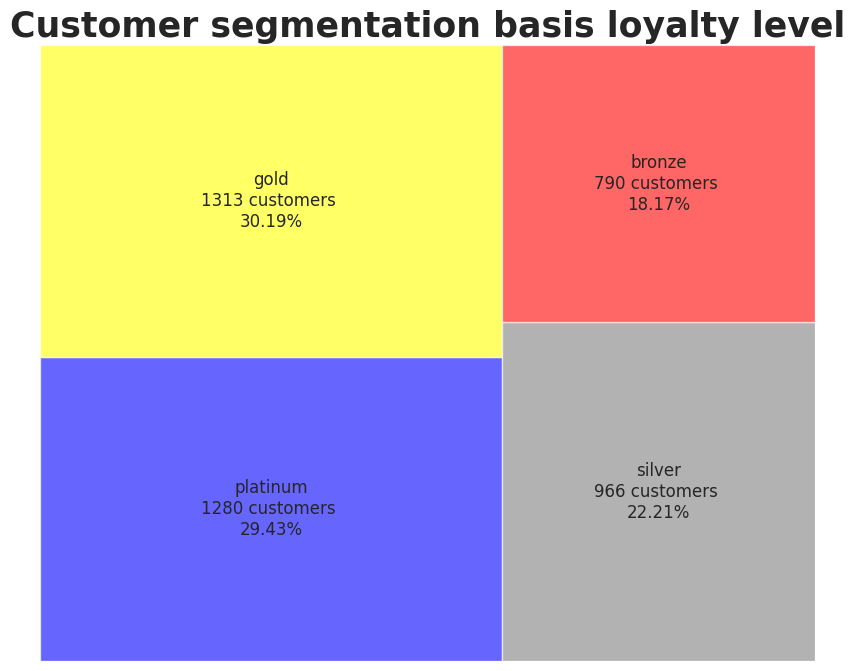

In [48]:
import squarify
fig = plt.gcf()
ax = fig.add_subplot()
fig.set_size_inches(10,8)
color_dics = {'platinum':'blue','gold':'yellow','silver':'gray','bronze':'red'}

squarify.plot(sizes = final_report_1['Buyers'], color = color_dics.values(),
              label = ['{}\n{:0.0f} customers \n{}%'.format(*final_report_1.iloc[i])for i in range(0,len(final_report_1))],alpha = 0.6)
plt.title('Customer segmentation basis loyalty level',fontsize = 25, fontweight = 'bold')
plt.axis('off')
plt.show()

Unsupervised Machine Learning - Segmentation/Clustering/Grouping

In [52]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import scipy.cluster.hierarchy as sch
from datetime import datetime

In [53]:
RFM.reset_index()

,index,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM,Loyalty_level
0,0,2.0,4,181,550416.0,1,1,1,3,platinum
1,1,3.0,77,27,257404.0,3,3,1,7,gold
2,2,4.0,19,72,176613.0,2,2,2,6,gold
3,3,5.0,311,16,41976.0,4,4,3,11,bronze
4,4,6.0,37,84,151822.0,2,2,2,6,gold
...,...,...,...,...,...,...,...,...,...,...
4344,4344,4368.0,278,10,20480.0,4,4,4,12,bronze
4345,4345,4369.0,181,7,10774.0,4,4,4,12,bronze
4346,4346,4370.0,9,13,24962.0,1,4,4,9,silver
4347,4347,4371.0,4,751,279720.0,1,1,1,3,platinum


In [54]:
RFM.columns

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R', 'F', 'M', 'RFM',
       'Loyalty_level'],
      dtype='object')

In [55]:
rfm_df = RFM[['Recency','Frequency','Monetary']]
rfm_df.head()

,Recency,Frequency,Monetary
0,4,181,550416.0
1,77,27,257404.0
2,19,72,176613.0
3,311,16,41976.0
4,37,84,151822.0


In [56]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_df)
rfm_scaled

array([[-0.88687668,  0.38301434,  0.37509732],
       [-0.16187726, -0.28447368,  0.0326216 ],
       [-0.73790419, -0.08942848, -0.06180783],
       ...,
       [-0.83721918, -0.34515441, -0.23905922],
       [-0.88687668,  2.85358691,  0.05870479],
       [-0.48961672, -0.10676583,  0.0320933 ]])

# Customer Segmentation(KMearn)

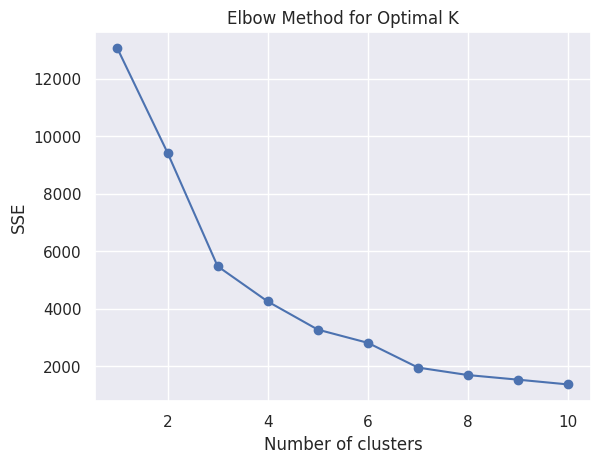

In [58]:
# Finding optimal clusters using elbow method
sse = []
for k in range(1,11):
  kmeans = KMeans(n_clusters = k,random_state = 42)
  kmeans.fit(rfm_scaled)
  sse.append(kmeans.inertia_)
plt.plot(range(1,11),sse,marker = 'o')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.title('Elbow Method for Optimal K')
plt.show()

In [60]:
kmeans = KMeans(n_clusters = 4, random_state = 42)
rfm_df['Kmeans_cluster'] = kmeans.fit_predict(rfm_scaled)


In [61]:
rfm_df

,Recency,Frequency,Monetary,Kmeans_cluster
0,4,181,550416.0,0
1,77,27,257404.0,0
2,19,72,176613.0,0
3,311,16,41976.0,1
4,37,84,151822.0,0
...,...,...,...,...
4344,278,10,20480.0,1
4345,181,7,10774.0,1
4346,9,13,24962.0,0
4347,4,751,279720.0,0


In [62]:
rfm_df['Kmeans_cluster'].value_counts()


,count
Kmeans_cluster,
0,3242
1,1092
3,11
2,4


# Hierarchical Clustering

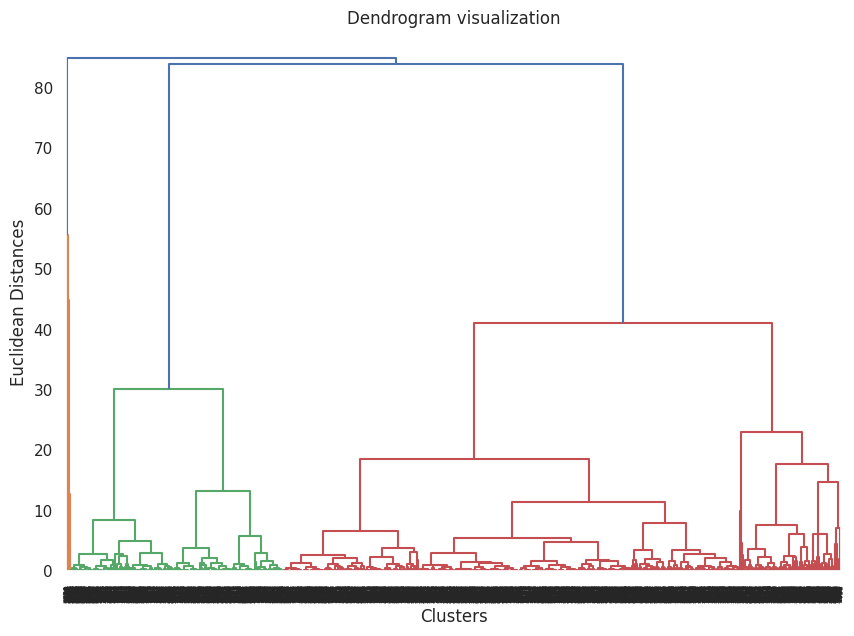

In [63]:
linked = linkage(rfm_scaled, method = 'ward')
plt.figure(figsize = (10,7))
dendrogram(linked)
plt.title('Dendrogram visualization')
plt.xlabel('Clusters')
plt.ylabel('Euclidean Distances')
plt.show()

In [64]:
rfm_df['Hierarchical_Cluster'] = fcluster(linked, 6, criterion = 'maxclust')
rfm_df

,Recency,Frequency,Monetary,Kmeans_cluster,Hierarchical_Cluster
0,4,181,550416.0,0,6
1,77,27,257404.0,0,5
2,19,72,176613.0,0,5
3,311,16,41976.0,1,4
4,37,84,151822.0,0,5
...,...,...,...,...,...
4344,278,10,20480.0,1,4
4345,181,7,10774.0,1,4
4346,9,13,24962.0,0,5
4347,4,751,279720.0,0,6


In [65]:
rfm_df['Hierarchical_Cluster'].value_counts()

,count
Hierarchical_Cluster,
5,2564
4,1197
6,566
2,17
1,4
3,1


# DBSCAN

In [66]:
dbscan = DBSCAN(eps = 1.5, min_samples = 5)
rfm_df['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)
rfm_df

,Recency,Frequency,Monetary,Kmeans_cluster,Hierarchical_Cluster,DBSCAN_Cluster
0,4,181,550416.0,0,6,0
1,77,27,257404.0,0,5,0
2,19,72,176613.0,0,5,0
3,311,16,41976.0,1,4,0
4,37,84,151822.0,0,5,0
...,...,...,...,...,...,...
4344,278,10,20480.0,1,4,0
4345,181,7,10774.0,1,4,0
4346,9,13,24962.0,0,5,0
4347,4,751,279720.0,0,6,0


In [67]:
rfm_df['DBSCAN_Cluster'].value_counts()

,count
DBSCAN_Cluster,
0,4330
-1,19


In [68]:
# -1 shows outliers

# COHORT analysis for customer retention

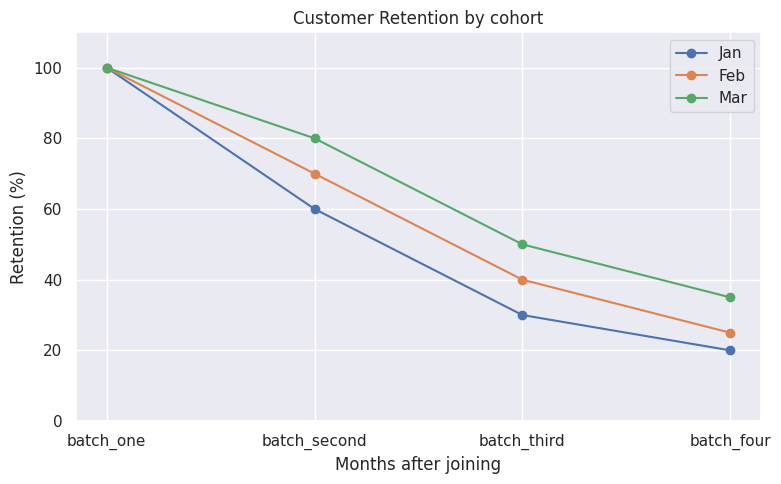

In [69]:
cohorts = ['Jan','Feb','Mar']
months = ['batch_one','batch_second','batch_third','batch_four']
retention_data = [[100,60,30,20],[100,70,40,25],[100,80,50,35]]
plt.figure(figsize = (8,5))
for i , cohort in enumerate(cohorts):
  plt.plot(months, retention_data[i],marker = 'o',label = cohort)
plt.title('Customer Retention by cohort')
plt.xlabel('Months after joining')
plt.ylabel('Retention (%)')
plt.ylim(0,110)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [70]:
df.head()

,CustomerID,InvoiceNo,Date,Price
0,4355.0,398177.0,2017-10-29,1926.0
1,4352.0,394422.0,2017-10-05,1740.0
2,4352.0,394422.0,2017-10-12,1866.0
3,4352.0,388633.0,2017-08-22,1869.0
4,4352.0,394422.0,2017-10-10,1888.0


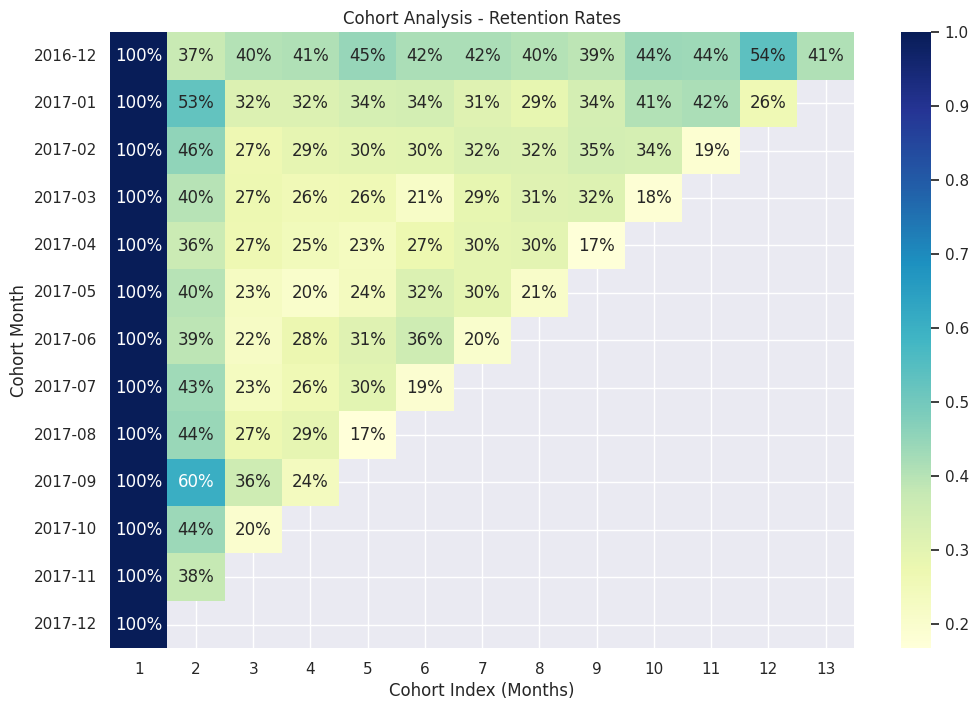

In [72]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')
df['CohortMonth'] = df.groupby('CustomerID')['Date'].transform('min').dt.to_period('M')
def cohort_index(df):
  year_diff = df['Month'].dt.year - df['CohortMonth'].dt.year
  month_diff = df['Month'].dt.month - df['CohortMonth'].dt.month
  return year_diff * 12 + month_diff +1
df['CohortIndex'] = cohort_index(df)
cohort_data = df.groupby(['CohortMonth','CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_counts = cohort_data.pivot_table(index = 'CohortMonth',columns = 'CohortIndex',values ='CustomerID' )
#Retention Rate
cohort_sizes = cohort_counts.iloc[:,0]
retention = cohort_counts.divide(cohort_sizes, axis = 0)

plt.figure(figsize = (12,8))
sns.heatmap(retention, annot = True, fmt = '.0%',cmap = 'YlGnBu')
plt.title('Cohort Analysis - Retention Rates')
plt.ylabel('Cohort Month')
plt.xlabel('Cohort Index (Months)')
plt.show()